# **EDA of Cleaned Datasets**

# All Imports Here

In [116]:
import os

gl_path = 'd:\\GitHub\\Falconstack_SaaS_Growth_Retention'
os.chdir(gl_path)
os.getcwd()

'd:\\GitHub\\Falconstack_SaaS_Growth_Retention'

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from Reusable_Python_Data.global_info import Global_Info
from Reusable_Python_Data.plotter import Plotter

# Importing Datasets

In [118]:
file_path = 'data\\cleaned'
accounts_clean_df = pd.read_csv(f'{gl_path}\\{file_path}\\accounts_cleaned.csv', index_col=False)
churn_events_clean_df = pd.read_csv(f'{gl_path}\\{file_path}\\churn_events_cleaned.csv', index_col=False)
feature_usage_clean_df = pd.read_csv(f'{gl_path}\\{file_path}\\feature_usage_cleaned.csv', index_col=False)
subscriptions_clean_df = pd.read_csv(f'{gl_path}\\{file_path}\\subscriptions_cleaned.csv', index_col=False)
support_tickets_clean_df = pd.read_csv(f'{gl_path}\\{file_path}\\support_tickets_cleaned.csv', index_col=False)

In [119]:
# confirm data load
churn_events_clean_df.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,27-10-2024,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,25-06-2024,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,12-11-2024,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,01-11-2023,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,30-12-2024,unknown,0.00,False,True,True,too expensive


# EDA

## *Accounts*

Questions

1. What are the min and max counts (not churned) for Industry, Country, Referral Source, Plan Tier, Is Trial, Seats?
2. Most signup by month per year
3. Account creation counts by sign up date broken down by Industry, Country, Referral Source, Plan Tier, Is Trial
4. Should we invest in free trial?
5. Which are churning more: Industry, Country, Referral Source, Plan Tier, Is Trial?
6. Which company holds the most accounts?



### **Question 1**

In [120]:
accounts_clean_df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,16-10-2024,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,17-08-2023,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,27-08-2024,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,27-08-2023,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,27-10-2024,event,Enterprise,35,False,True


In [127]:
# question 1
# What are the min and max counts (not churned) for Industry, Country, Referral Source, Plan Tier, Is Trial, Seats?
cat_cols = ['industry', 'country', 'referral_source', 'plan_tier', 'is_trial']
no_churned_accounts = accounts_clean_df[accounts_clean_df['churn_flag'] == False]
print(no_churned_accounts.shape)
print(Global_Info.cat_max_min(no_churned_accounts, cat_cols=cat_cols))
print(f'\nSeats:\n{no_churned_accounts['seats'].agg(['min', 'max'])}')

(412, 10)
            Column Most Frequent  Max Count Least Frequent  Min Count
0         industry       FinTech         90         EdTech         71
1          country            US        238             DE         17
2  referral_source       organic         98          event         71
3        plan_tier           Pro        147     Enterprise        126
4         is_trial         False        338           True         74

Seats:
min      1
max    163
Name: seats, dtype: int64


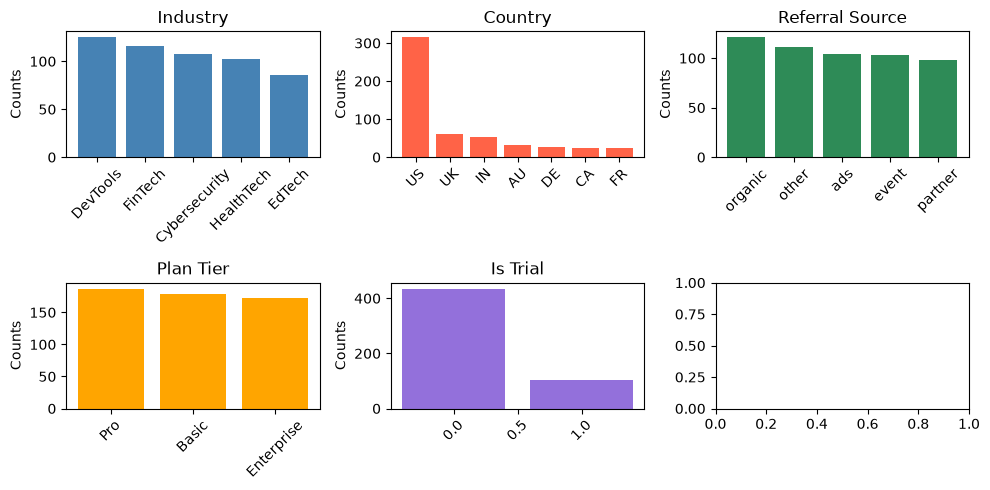

In [122]:
# plot question 1
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']

plotter = Plotter(cols=cat_cols, colors=colors, df=accounts_clean_df)
plotter.subplotter_cat_bar()


### **Question 2**

C:\Users\Ujjwal Karki\AppData\Local\Temp\ipykernel_19232\1658304514.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  accounts_clean_df['signup_date'] = pd.to_datetime(accounts_clean_df['signup_date'])


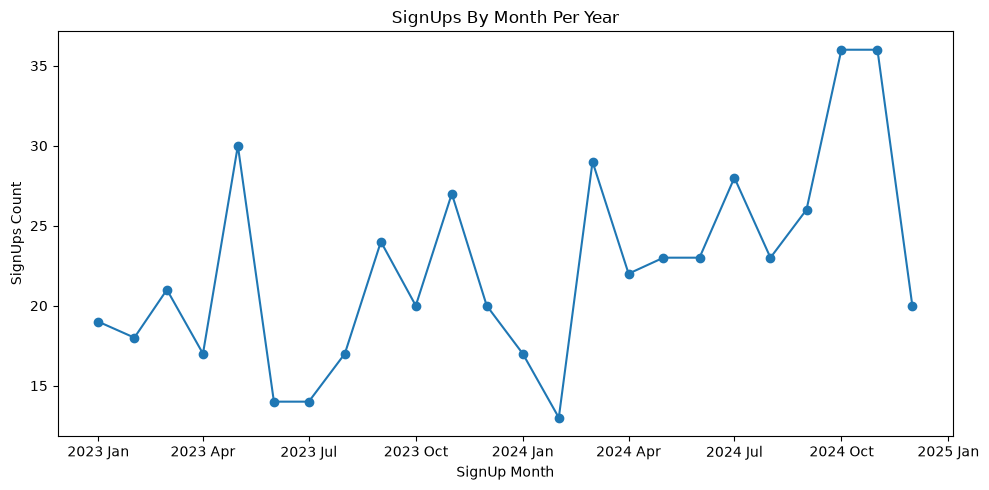

In [123]:
# question 2
# Most signup by month per year
accounts_clean_df['signup_date'] = pd.to_datetime(accounts_clean_df['signup_date'])

signups_mnth = (
    accounts_clean_df.groupby(accounts_clean_df['signup_date'].dt.to_period('M')).size()
)

x = signups_mnth.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(x, signups_mnth.values, marker='o')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y %b"))

plt.title('SignUps By Month Per Year')
plt.xlabel('SignUp Month')
plt.ylabel('SignUps Count')
plt.tight_layout()
plt.show()

### **Question 3**

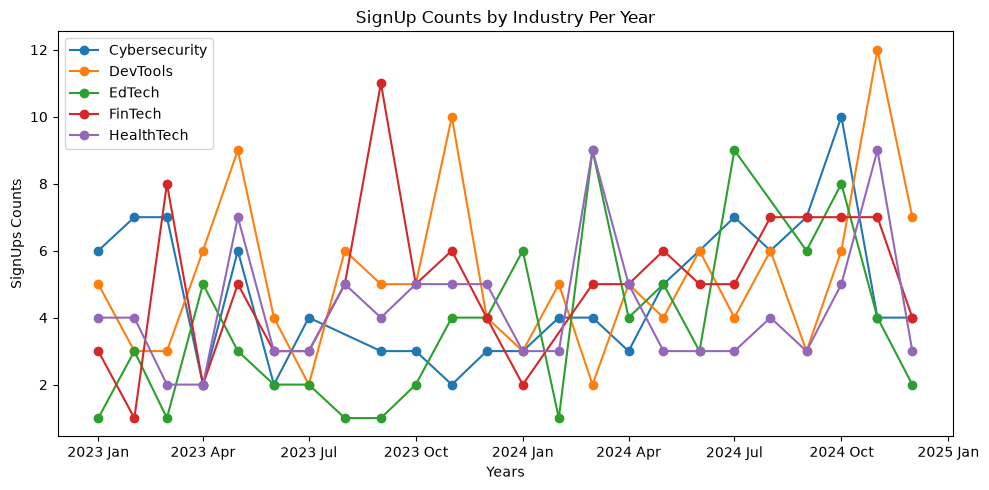

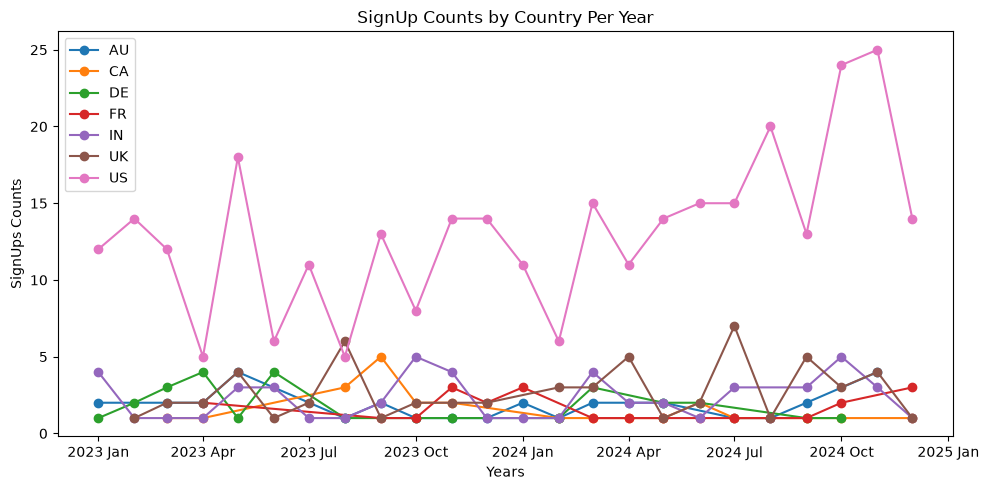

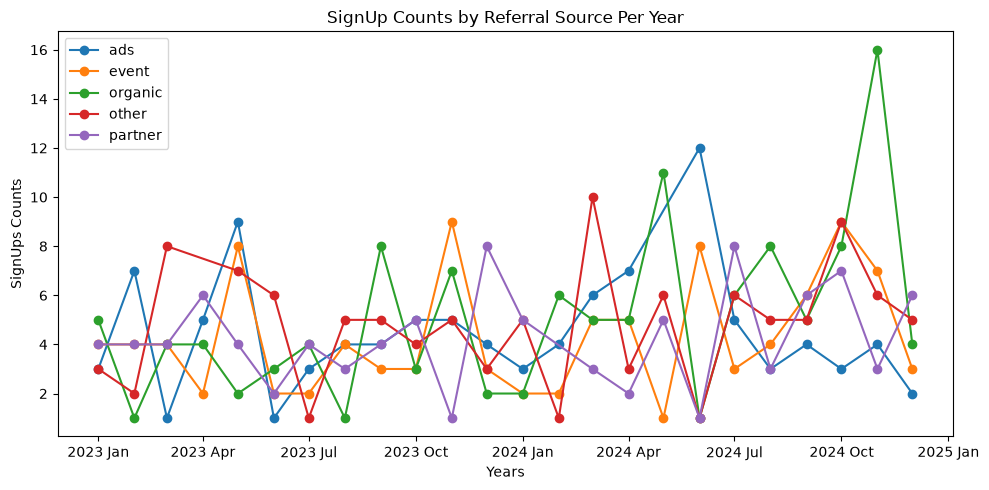

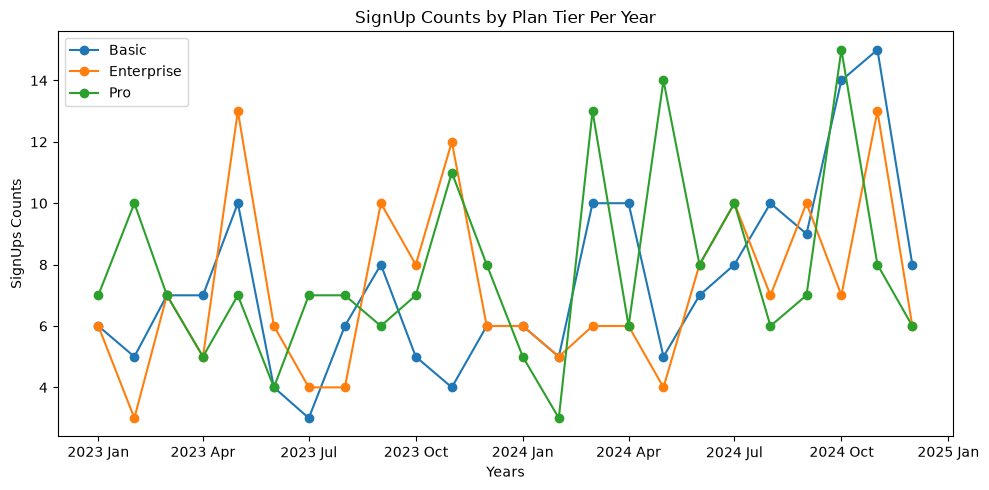

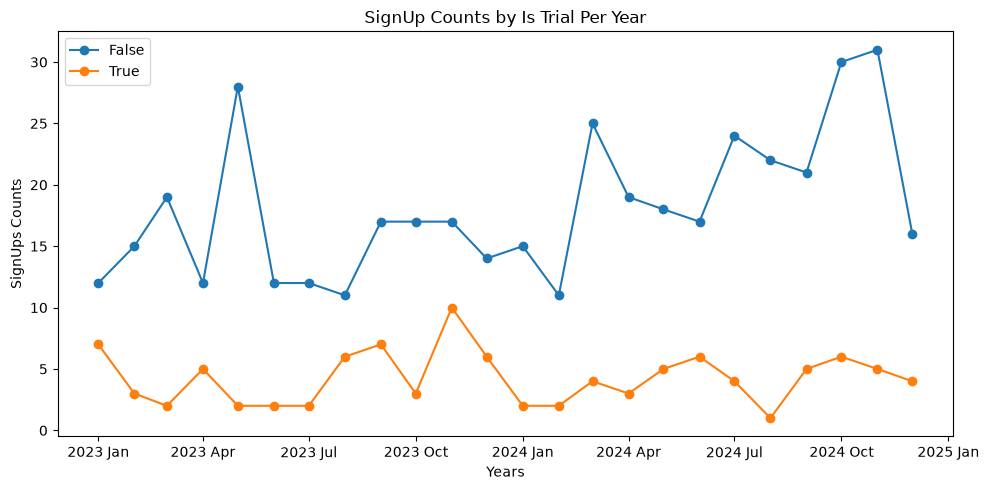

In [124]:
# question 3
# Account creation counts by sign up date broken down by Industry, Country, Referral Source, Plan Tier, Is Trial

for col in cat_cols:
    signups_yr = (
        accounts_clean_df
        .groupby([
            accounts_clean_df['signup_date'].dt.to_period('M'), col])
            .size()
            .reset_index(name='signup_count')
        # size counts rows for each group, and unlike count, it even counts when col values are missing
    )

    signups_yr['signup_date'] = signups_yr['signup_date'].dt.to_timestamp()

    plt.figure(figsize=(10, 5))

    for cat, group in signups_yr.groupby(col):
        plt.plot(group['signup_date'], group['signup_count'], marker='o', label=cat)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y %b"))

    plt.title(f'SignUp Counts by {col.replace("_", " ").title()} Per Year')
    plt.xlabel('Years')
    plt.ylabel('SignUps Counts')
    plt.legend()
    plt.tight_layout()
    plt.show()

### **Question 4**

Ans is no for now, as most are directly using paid versions

### **Question 5**

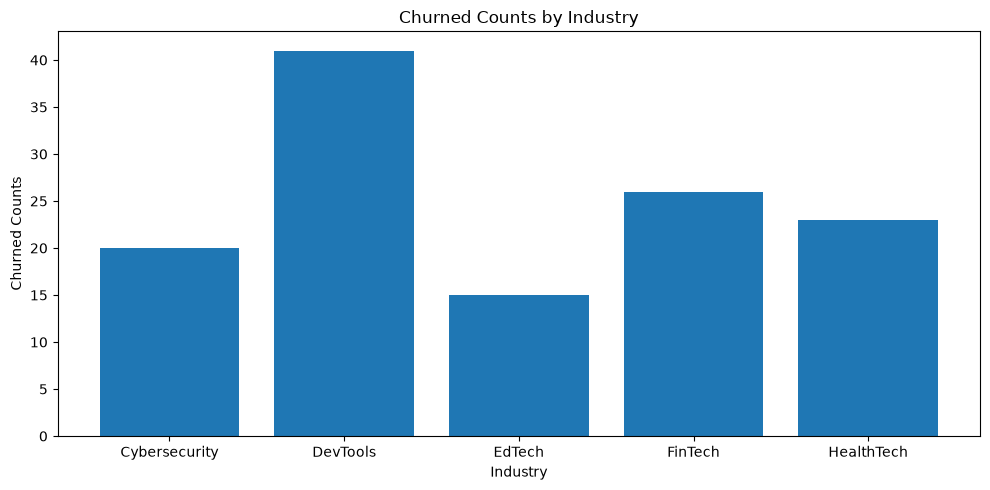

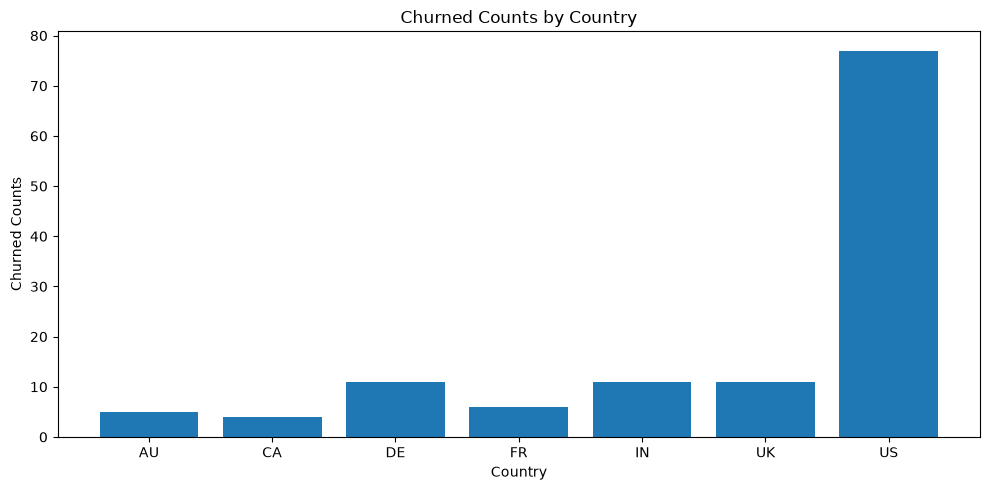

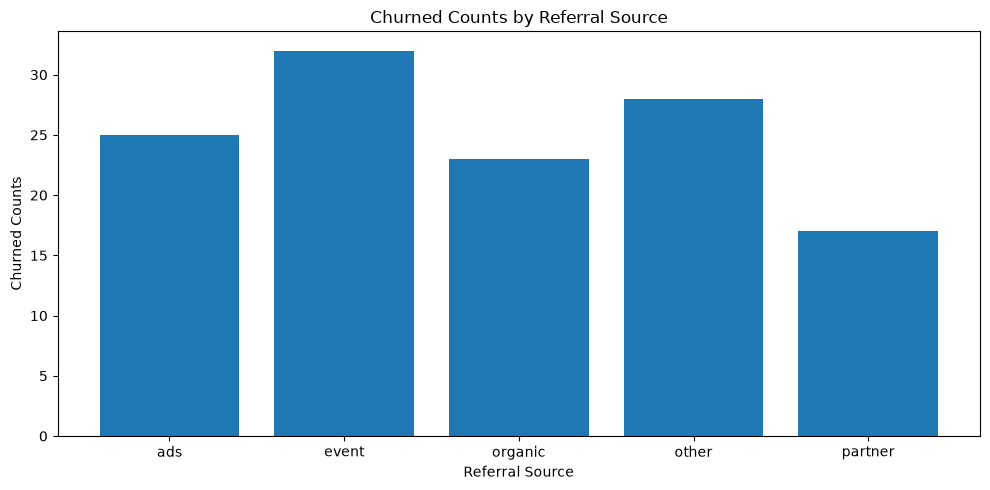

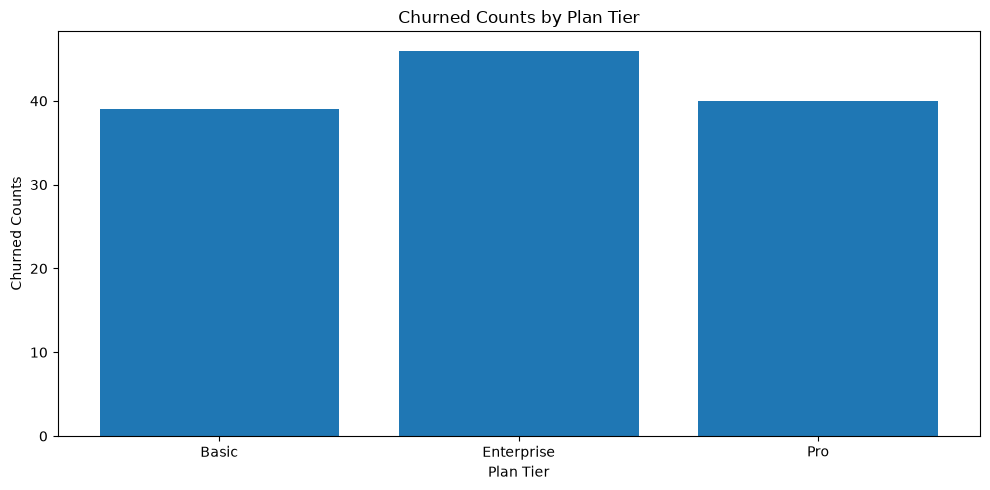

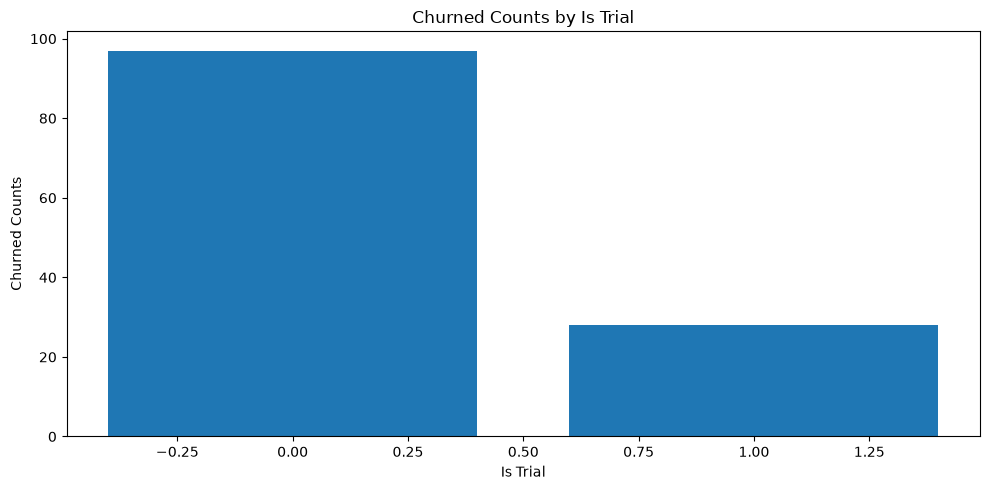

In [125]:
# question 5
# Which are churning more: Industry, Country, Referral Source, Plan Tier, Is Trial?
churned_rate = {}

for col in cat_cols:
    churned_rate[col] = (
        accounts_clean_df[accounts_clean_df['churn_flag'] == True]
        .groupby(col)
        .size()
    )

for col, val in churned_rate.items():
    plt.figure(figsize=(10, 5))
    plt.bar(val.index, val.values, label=val.index)
    plt.xlabel(f'{col.replace('_', ' ').title()}')
    plt.ylabel('Churned Counts')
    plt.title(f'Churned Counts by {col.replace('_', ' ').title()}')
    plt.tight_layout()
    plt.show()

### **Question 6**

In [126]:
# question 6
# Which company holds the most accounts?
comp_acc_count = accounts_clean_df.groupby('account_name')['account_id'].size().sort_values(ascending=False).reset_index()
comp_acc_count.agg(['min', 'max'])
# insight: most companies hold 2 accounts while others hold 1, so there's no actual single company

,account_name,account_id
min,Company_0,1
max,Company_99,2


### **Key Findings**

- (not churned) (approx.) 58% customers are from US
- (not churned) All three plan tiers are equally used
- (not churned) (approx.) 82% use paid plan with only very few (approx.) 18% using free trial
- First quarter of 2024 saw the lowest signups whereas, last quarter of 2024 saw the highest signups
- DevTools Signups shows the most spikes which hold true with industry signup count distribution. FinTech follows. Interestingly, DevTools shows spike around the last quarter of 2023 as well as 2024, maybe a pattern?
- Interestingly, Organic Referral Source also shows spike at the last quarter of 2024
- Enterprise plan tier had the most churns

## *Features*

Questions

1. Which features are used most by upgraded or high-MRR subscriptions?
2. Does higher feature usage relate to upgrades, seat growth, or higher revenue?
3. Are beta features associated with stronger engagement?
4. Which features have the highest error counts?
5. Do low usage or high errors appear before churn?
6. Which features are most used by retained customers?

## *Support Tickets*

Questions

1. Are accounts with more tickets more likely to churn?
2. Do longer response or resolution times relate to churn?
3. Are escalated tickets associated with lower retention?
4. Does satisfaction score relate to upgrades or churn?
5. Which accounts generate the most support workload?
6. Do faster support outcomes relate to better account growth?


## *Subscriptions*

Questions

1. Which plan tier generates the highest MRR and ARR?
2. Which plans receive the most upgrades and downgrades?
3. Are trial subscriptions converting into paid accounts?
4. Does auto-renew reduce churn?
5. Which billing frequency has the strongest retention?
6. How do subscriptions, seats, MRR, and ARR change over time?

## *Churn Events*

Questions

1. What are the most common churn reasons?
2. Which churn reasons cause the highest refund losses?
3. Do downgrades commonly happen before churn?
4. Are previously upgraded customers less likely to churn permanently?
5. Which churn reasons have the highest reactivation rates?
6. How does churn change over time?